# 5.0 Enhanced Model — Player-Level Analysis V3

Expanded feature set: Elo-weighted stats, attack-vs-defense mismatches, WC pedigree, squad cohesion, defending champion, and shrinkage-adjusted rates.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.linear_model import (
    LogisticRegression,
    LogisticRegressionCV,
    LinearRegression,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

## 5.1 Load & Team-Level Aggregation

In [ ]:
df = pd.read_csv("player_stats_v2.csv")
matches = pd.read_csv("match_features_base.csv")
elo = pd.read_csv("/Users/banna/Desktop/player_analysis/data/World_Cup/elo_ratings.csv")
roster = pd.read_csv("player_rosters.csv")

# Rejoin WC stats
wc_cols = ["key_id", "matches_played", "starts", "goals", "yellow_cards"]
roster_wc = roster[wc_cols].rename(
    columns={"goals": "wc_goals", "yellow_cards": "wc_yellow_cards"}
)
df = df.merge(roster_wc, on="key_id", how="left")

active = df[df["has_stats"] == True].copy()
wc_matches = matches[matches["tournament_id"].str.startswith("WC-")].copy()

WC_YEAR = {
    "WC-2006": 2006,
    "WC-2010": 2010,
    "WC-2014": 2014,
    "WC-2018": 2018,
    "WC-2022": 2022,
}
TEAM_NAME_FIX = {"Czech Republic": "Czechia", "Serbia and Montenegro": "Serbia"}
STAGE_ORDER = {
    "group stage": 0,
    "round of 16": 1,
    "round of sixteen": 1,
    "quarter-finals": 2,
    "quarter-final": 2,
    "semi-finals": 3,
    "semi-final": 3,
    "third-place match": 3,
    "third place match": 3,
    "final": 4,
}

print(f"Players: {active.shape}")
print(f"Matches: {wc_matches.shape}")

Players: (2663, 66)
Matches: (488, 35)


In [ ]:
def weighted_mean(group, col, weight_col="total_appearances"):
    w = group[weight_col].fillna(0)
    v = group[col].fillna(0)
    if w.sum() == 0:
        return np.nan
    return np.average(v, weights=w)


team_features = []
for (wc, team), grp in active.groupby(["wc_tournament", "national_team"]):
    row = {"wc_tournament": wc, "national_team": team}

    # ── Positional MV ──────────────────────────────────────────────────
    for pos in ["FW", "MF", "DF"]:
        pg = grp[grp["position_code"] == pos]
        row[f"{pos}_avg_mv"] = pg["market_value"].mean() if len(pg) > 0 else np.nan

    # ── Adjusted rates (shrinkage) ─────────────────────────────────────
    row["squad_goals_per_app"] = weighted_mean(grp, "goals_per_app_adj")
    row["squad_assists_per_app"] = weighted_mean(grp, "assists_per_app_adj")
    row["FW_goals_per_app"] = (
        weighted_mean(grp[grp["position_code"] == "FW"], "goals_per_app_adj")
        if len(grp[grp["position_code"] == "FW"]) > 0
        else np.nan
    )
    row["MF_assists_per_app"] = (
        weighted_mean(grp[grp["position_code"] == "MF"], "assists_per_app_adj")
        if len(grp[grp["position_code"] == "MF"]) > 0
        else np.nan
    )

    # ── Elo-weighted stats ─────────────────────────────────────────────
    row["squad_goals_elo_wt"] = grp["goals_elo_weighted"].sum()
    row["squad_assists_elo_wt"] = grp["assists_elo_weighted"].sum()
    row["FW_goals_elo_wt"] = grp[grp["position_code"] == "FW"][
        "goals_elo_weighted"
    ].sum()
    row["MF_assists_elo_wt"] = grp[grp["position_code"] == "MF"][
        "assists_elo_weighted"
    ].sum()

    # ── Club Elo (avg per squad) ───────────────────────────────────────
    row["squad_avg_club_elo"] = grp["club_elo"].mean()

    # ── Offensive / Defensive composites ───────────────────────────────
    off = grp[grp["role"] == "offensive"]
    defe = grp[grp["role"] == "defensive"]
    row["offensive_score"] = off["offensive_score"].mean() if len(off) > 0 else np.nan
    row["defensive_mv"] = defe["market_value"].mean() if len(defe) > 0 else np.nan

    gk = grp[grp["position_code"] == "GK"]
    row["GK_clean_sheet_rate"] = (
        weighted_mean(gk, "clean_sheet_rate") if len(gk) > 0 else np.nan
    )

    # ── Club context ───────────────────────────────────────────────────
    row["squad_avg_club_pos"] = grp["club_league_position"].mean()

    # ── Squad-level features (same for all players on team) ────────────
    first = grp.iloc[0]
    row["wc_pedigree_wins"] = first.get("wc_total_wins", 0)
    row["wc_pedigree_finals"] = first.get("wc_finals", 0)
    row["wc_pedigree_appearances"] = first.get("wc_appearances", 0)
    row["defending_champion"] = first.get("defending_champion", 0)
    row["squad_club_pairs"] = first.get("squad_club_pairs", 0)
    row["largest_club_block"] = first.get("largest_club_block", 0)

    team_features.append(row)

team_df = pd.DataFrame(team_features)

# ── Add national team Elo ──────────────────────────────────────────────
team_df["wc_year"] = team_df["wc_tournament"].map(WC_YEAR)
team_df["elo_team"] = team_df["national_team"].replace(TEAM_NAME_FIX)
elo_merge = elo[["year", "team", "rating"]].rename(
    columns={"year": "wc_year", "team": "elo_team", "rating": "elo_rating"}
)
team_df = team_df.merge(elo_merge, on=["wc_year", "elo_team"], how="left")

print(f"Team features: {team_df.shape}")
print(f"Columns: {team_df.columns.tolist()}")

Team features: (158, 27)
Columns: ['wc_tournament', 'national_team', 'FW_avg_mv', 'MF_avg_mv', 'DF_avg_mv', 'squad_goals_per_app', 'squad_assists_per_app', 'FW_goals_per_app', 'MF_assists_per_app', 'squad_goals_elo_wt', 'squad_assists_elo_wt', 'FW_goals_elo_wt', 'MF_assists_elo_wt', 'squad_avg_club_elo', 'offensive_score', 'defensive_mv', 'GK_clean_sheet_rate', 'squad_avg_club_pos', 'wc_pedigree_wins', 'wc_pedigree_finals', 'wc_pedigree_appearances', 'defending_champion', 'squad_club_pairs', 'largest_club_block', 'wc_year', 'elo_team', 'elo_rating']


## 5.2 Pairwise Differentials

Includes standard like-for-like differentials plus attack-vs-defense mismatches.

In [ ]:
DIFF_FEATURES = [
    # Baseline
    "elo_rating",
    # Positional MV
    "FW_avg_mv",
    "DF_avg_mv",
    # Adjusted rates
    "squad_goals_per_app",
    "squad_assists_per_app",
    "FW_goals_per_app",
    "MF_assists_per_app",
    # Elo-weighted volume
    "squad_goals_elo_wt",
    "FW_goals_elo_wt",
    "MF_assists_elo_wt",
    # Club Elo
    "squad_avg_club_elo",
    # Club context
    "squad_avg_club_pos",
    # Defensive
    "defensive_mv",
    "GK_clean_sheet_rate",
    # Pedigree & context
    "wc_pedigree_wins",
    "defending_champion",
    "squad_club_pairs",
]

# Mismatch features computed separately (A's attack vs B's defense)
MISMATCH_FEATURES = [
    ("offensive_score", "defensive_mv"),  # A's attack vs B's defense
]


def build_match_matrix(match_df, team_df, features, mismatch_features):
    rows = []
    for _, m in match_df.iterrows():
        wc = m["tournament_id"]
        home = m["team_name_home"]
        away = m["team_name_away"]

        home_row = team_df[
            (team_df["wc_tournament"] == wc) & (team_df["national_team"] == home)
        ]
        away_row = team_df[
            (team_df["wc_tournament"] == wc) & (team_df["national_team"] == away)
        ]

        if len(home_row) == 0 or len(away_row) == 0:
            continue

        hr, ar = home_row.iloc[0], away_row.iloc[0]

        row = {
            "match_id": m["match_id"],
            "wc_tournament": wc,
            "wc_year": WC_YEAR.get(wc, 0),
            "home_team": home,
            "away_team": away,
            "goal_diff": m["goals_for_home"] - m["goals_for_away"],
            "result": m["result_home"],
            "stage": m["stage_name"],
            "knockout": m["knockout_stage"],
        }

        for feat in features:
            h, a = hr.get(feat, np.nan), ar.get(feat, np.nan)
            row[f"diff_{feat}"] = h - a if pd.notna(h) and pd.notna(a) else np.nan

        # Mismatch: home attack vs away defense, and vice versa
        for off_feat, def_feat in mismatch_features:
            h_off, a_def = hr.get(off_feat, np.nan), ar.get(def_feat, np.nan)
            a_off, h_def = ar.get(off_feat, np.nan), hr.get(def_feat, np.nan)
            if pd.notna(h_off) and pd.notna(a_def):
                row[f"mismatch_home_attack"] = h_off - (
                    a_def / 1e7 if a_def > 100 else a_def
                )
            else:
                row[f"mismatch_home_attack"] = np.nan
            if pd.notna(a_off) and pd.notna(h_def):
                row[f"mismatch_away_attack"] = a_off - (
                    h_def / 1e7 if h_def > 100 else h_def
                )
            else:
                row[f"mismatch_away_attack"] = np.nan

        # Net mismatch advantage
        if pd.notna(row.get("mismatch_home_attack")) and pd.notna(
            row.get("mismatch_away_attack")
        ):
            row["mismatch_net"] = (
                row["mismatch_home_attack"] - row["mismatch_away_attack"]
            )
        else:
            row["mismatch_net"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


match_df = build_match_matrix(wc_matches, team_df, DIFF_FEATURES, MISMATCH_FEATURES)

RESULT_MAP = {"W": 2, "D": 1, "L": 0}
match_df["result_enc"] = match_df["result"].map(RESULT_MAP)

print(f"Match matrix: {match_df.shape}")
print(f"Result distribution:\n{match_df['result'].value_counts()}")
print(f"\nMissing per feature:")
feat_cols = [
    c for c in match_df.columns if c.startswith("diff_") or c.startswith("mismatch_")
]
print(match_df[feat_cols].isna().sum().to_string())

Match matrix: (314, 30)
Result distribution:
result
W    146
L    116
D     52
Name: count, dtype: int64

Missing per feature:
diff_elo_rating                0
diff_FW_avg_mv                 7
diff_DF_avg_mv                 6
diff_squad_goals_per_app       0
diff_squad_assists_per_app     0
diff_FW_goals_per_app          7
diff_MF_assists_per_app        9
diff_squad_goals_elo_wt        0
diff_FW_goals_elo_wt           0
diff_MF_assists_elo_wt         0
diff_squad_avg_club_elo        9
diff_squad_avg_club_pos        6
diff_defensive_mv              6
diff_GK_clean_sheet_rate      74
diff_wc_pedigree_wins          0
diff_defending_champion        0
diff_squad_club_pairs          0
mismatch_home_attack           5
mismatch_away_attack           4
mismatch_net                   9


## 5.3 Multicollinearity Check

In [ ]:
feat_cols = [
    c for c in match_df.columns if c.startswith("diff_") or c.startswith("mismatch_")
]
clean = match_df[feat_cols + ["result_enc", "wc_year"]].dropna().copy()
print(f"Clean rows: {len(clean)}/{len(match_df)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(clean[feat_cols])

vif_data = pd.DataFrame(
    {
        "Feature": feat_cols,
        "VIF": [
            variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])
        ],
    }
).sort_values("VIF", ascending=False)

print("\n=== VIF ===")
print(vif_data.to_string(index=False))

Clean rows: 238/314

=== VIF ===
                   Feature        VIF
              mismatch_net        inf
      mismatch_away_attack        inf
      mismatch_home_attack        inf
         diff_defensive_mv 432.901165
   diff_squad_goals_elo_wt  42.358649
            diff_DF_avg_mv  28.088161
      diff_FW_goals_elo_wt  16.705352
    diff_MF_assists_elo_wt  10.594495
            diff_FW_avg_mv   5.501828
   diff_squad_avg_club_elo   4.639336
diff_squad_assists_per_app   4.505459
   diff_MF_assists_per_app   4.071316
  diff_squad_goals_per_app   3.883654
     diff_wc_pedigree_wins   3.294947
           diff_elo_rating   3.248631
     diff_squad_club_pairs   2.821751
     diff_FW_goals_per_app   2.739437
   diff_squad_avg_club_pos   2.529274
   diff_defending_champion   1.352677
  diff_GK_clean_sheet_rate   1.139523


In [10]:
# Iterative VIF removal
feat_cols_final = feat_cols.copy()
dropped = []

while True:
    X_sc = scaler.fit_transform(clean[feat_cols_final])
    vifs = [variance_inflation_factor(X_sc, i) for i in range(X_sc.shape[1])]
    vif_df = pd.DataFrame({"Feature": feat_cols_final, "VIF": vifs})
    max_vif = vif_df["VIF"].max()
    if max_vif <= 5:
        break
    worst = vif_df.loc[vif_df["VIF"].idxmax(), "Feature"]
    feat_cols_final.remove(worst)
    dropped.append(worst)
    print(f"Dropped {worst} (VIF={max_vif:.1f})")

print(f"\nDropped: {dropped}")
print(f"Remaining ({len(feat_cols_final)}): {feat_cols_final}")

Dropped mismatch_home_attack (VIF=inf)
Dropped mismatch_net (VIF=494.5)
Dropped diff_defensive_mv (VIF=36.4)
Dropped diff_squad_goals_elo_wt (VIF=34.0)
Dropped diff_DF_avg_mv (VIF=6.1)

Dropped: ['mismatch_home_attack', 'mismatch_net', 'diff_defensive_mv', 'diff_squad_goals_elo_wt', 'diff_DF_avg_mv']
Remaining (15): ['diff_elo_rating', 'diff_FW_avg_mv', 'diff_squad_goals_per_app', 'diff_squad_assists_per_app', 'diff_FW_goals_per_app', 'diff_MF_assists_per_app', 'diff_FW_goals_elo_wt', 'diff_MF_assists_elo_wt', 'diff_squad_avg_club_elo', 'diff_squad_avg_club_pos', 'diff_GK_clean_sheet_rate', 'diff_wc_pedigree_wins', 'diff_defending_champion', 'diff_squad_club_pairs', 'mismatch_away_attack']


## 5.4 Temporal Cross-Validation

In [11]:
FOLDS = [
    ("2014", [2006, 2010], 2014),
    ("2018", [2006, 2010, 2014], 2018),
    ("2022", [2006, 2010, 2014, 2018], 2022),
]

## 5.5 Elo-Only Baseline

In [ ]:
elo_results = []
for fold_name, train_years, test_year in FOLDS:
    train = clean[clean["wc_year"].isin(train_years)]
    test = clean[clean["wc_year"] == test_year]
    if len(test) == 0:
        continue

    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(C=1.0, max_iter=2000, random_state=42)),
        ]
    )
    model.fit(train[["diff_elo_rating"]], train["result_enc"])

    preds = model.predict(test[["diff_elo_rating"]])
    probas = model.predict_proba(test[["diff_elo_rating"]])
    acc = accuracy_score(test["result_enc"], preds)
    f1 = f1_score(test["result_enc"], preds, average="macro")
    ll = log_loss(test["result_enc"], probas)

    elo_results.append(
        {"fold": fold_name, "accuracy": acc, "f1_macro": f1, "log_loss": ll}
    )
    print(f"[{fold_name}] acc={acc:.3f} | f1={f1:.3f} | ll={ll:.3f}")

elo_baseline = pd.DataFrame(elo_results)
print(
    f"\nElo avg: acc={elo_baseline['accuracy'].mean():.3f} f1={elo_baseline['f1_macro'].mean():.3f} ll={elo_baseline['log_loss'].mean():.3f}"
)

[2014] acc=0.800 | f1=0.547 | ll=0.614
[2018] acc=0.707 | f1=0.509 | ll=0.845
[2022] acc=0.625 | f1=0.447 | ll=0.978

Elo avg: acc=0.711 f1=0.501 ll=0.812


## 5.6 L1 Logistic Regression

In [ ]:
l1_results = []
l1_models = {}

for fold_name, train_years, test_year in FOLDS:
    train = clean[clean["wc_year"].isin(train_years)]
    test = clean[clean["wc_year"] == test_year]
    if len(test) == 0:
        continue

    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegressionCV(
                    penalty="l1",
                    solver="liblinear",
                    Cs=np.logspace(-3, 2, 20),
                    cv=3,
                    max_iter=2000,
                    random_state=42,
                    scoring="neg_log_loss",
                ),
            ),
        ]
    )
    model.fit(train[feat_cols_final], train["result_enc"])

    preds = model.predict(test[feat_cols_final])
    probas = model.predict_proba(test[feat_cols_final])
    acc = accuracy_score(test["result_enc"], preds)
    f1 = f1_score(test["result_enc"], preds, average="macro")
    ll = log_loss(test["result_enc"], probas)

    l1_results.append(
        {
            "fold": fold_name,
            "accuracy": acc,
            "f1_macro": f1,
            "log_loss": ll,
            "best_C": model.named_steps["clf"].C_[0],
        }
    )
    l1_models[fold_name] = model
    print(
        f"[{fold_name}] acc={acc:.3f} | f1={f1:.3f} | ll={ll:.3f} | C={model.named_steps['clf'].C_[0]:.4f}"
    )

l1_df = pd.DataFrame(l1_results)
print(
    f"\nL1 avg: acc={l1_df['accuracy'].mean():.3f} f1={l1_df['f1_macro'].mean():.3f} ll={l1_df['log_loss'].mean():.3f}"
)

[2014] acc=0.711 | f1=0.489 | ll=0.810 | C=1.4384
[2018] acc=0.638 | f1=0.459 | ll=0.816 | C=0.4281
[2022] acc=0.625 | f1=0.448 | ll=1.012 | C=0.4281

L1 avg: acc=0.658 f1=0.465 ll=0.879


In [ ]:
# Coefficients
latest = l1_models[list(l1_models.keys())[-1]]
clf = latest.named_steps["clf"]
classes = clf.classes_

coef_df = pd.DataFrame(
    clf.coef_.T, index=feat_cols_final, columns=[f"class_{c}" for c in classes]
)
coef_df["abs_max"] = coef_df.abs().max(axis=1)
coef_df = coef_df.sort_values("abs_max", ascending=False)

print("=== L1 Coefficients (latest fold) ===")
print(coef_df.to_string())
print(f"\nZeroed: {(coef_df['abs_max'] == 0).sum()}/{len(coef_df)}")

=== L1 Coefficients (latest fold) ===
                             class_0   class_1   class_2   abs_max
diff_elo_rating            -2.124644  0.000000  1.763499  2.124644
diff_defending_champion     0.210485  0.000000 -0.318009  0.318009
diff_GK_clean_sheet_rate   -0.312948  0.050056  0.123309  0.312948
mismatch_away_attack       -0.260289  0.000000  0.098976  0.260289
diff_squad_avg_club_pos     0.000000  0.033450 -0.212990  0.212990
diff_squad_goals_per_app    0.000000  0.122062 -0.182881  0.182881
diff_wc_pedigree_wins       0.093017  0.000000 -0.144746  0.144746
diff_squad_avg_club_elo     0.143963  0.000000 -0.064781  0.143963
diff_FW_goals_per_app      -0.116104  0.123959  0.000000  0.123959
diff_MF_assists_elo_wt      0.009917  0.000000  0.000000  0.009917
diff_FW_avg_mv              0.000000  0.000000  0.000000  0.000000
diff_squad_assists_per_app  0.000000  0.000000  0.000000  0.000000
diff_MF_assists_per_app     0.000000  0.000000  0.000000  0.000000
diff_FW_goals_elo_wt    

## 5.7 Elo-Orthogonal Residuals

In [ ]:
residual_features = [c for c in feat_cols_final if c != "diff_elo_rating"]
residual_df = clean.copy()

for col in residual_features:
    lr = LinearRegression()
    mask = residual_df[[col, "diff_elo_rating"]].notna().all(axis=1)
    X_elo = residual_df.loc[mask, "diff_elo_rating"].values.reshape(-1, 1)
    y_feat = residual_df.loc[mask, col].values
    lr.fit(X_elo, y_feat)
    residual_df.loc[mask, f"resid_{col}"] = y_feat - lr.predict(X_elo)

resid_cols = [f"resid_{c}" for c in residual_features]
resid_feat_cols = ["diff_elo_rating"] + resid_cols

resid_results = []
for fold_name, train_years, test_year in FOLDS:
    train = residual_df[residual_df["wc_year"].isin(train_years)]
    test = residual_df[residual_df["wc_year"] == test_year]
    if len(test) == 0:
        continue

    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegressionCV(
                    penalty="l1",
                    solver="liblinear",
                    Cs=np.logspace(-3, 2, 20),
                    cv=3,
                    max_iter=2000,
                    random_state=42,
                    scoring="neg_log_loss",
                ),
            ),
        ]
    )
    model.fit(train[resid_feat_cols], train["result_enc"])

    preds = model.predict(test[resid_feat_cols])
    probas = model.predict_proba(test[resid_feat_cols])
    acc = accuracy_score(test["result_enc"], preds)
    f1 = f1_score(test["result_enc"], preds, average="macro")
    ll = log_loss(test["result_enc"], probas)

    resid_results.append(
        {"fold": fold_name, "accuracy": acc, "f1_macro": f1, "log_loss": ll}
    )
    print(f"[{fold_name}] acc={acc:.3f} | f1={f1:.3f} | ll={ll:.3f}")

    surviving = pd.Series(
        model.named_steps["clf"].coef_[
            list(model.named_steps["clf"].classes_).index(2)
        ],
        index=resid_feat_cols,
    )
    print(f"  Surviving: {surviving[surviving != 0].to_dict()}")

resid_df_results = pd.DataFrame(resid_results)
print(
    f"\nResidual avg: acc={resid_df_results['accuracy'].mean():.3f} f1={resid_df_results['f1_macro'].mean():.3f} ll={resid_df_results['log_loss'].mean():.3f}"
)

[2014] acc=0.733 | f1=0.517 | ll=0.803
  Surviving: {'diff_elo_rating': 0.6935326662353725, 'resid_diff_MF_assists_per_app': 0.042624195052985786, 'resid_diff_wc_pedigree_wins': -0.38900074072342355, 'resid_diff_defending_champion': -0.03184851630113538}
[2018] acc=0.638 | f1=0.459 | ll=0.831
  Surviving: {'diff_elo_rating': 1.4150373695870888, 'resid_diff_GK_clean_sheet_rate': 0.02754576811344685, 'resid_diff_defending_champion': -0.25089003168641666, 'resid_mismatch_away_attack': 0.13176821326573118}
[2022] acc=0.643 | f1=0.465 | ll=1.002
  Surviving: {'diff_elo_rating': 1.5682200498355805, 'resid_diff_squad_goals_per_app': -0.18585911301866317, 'resid_diff_squad_avg_club_elo': -0.14699701326930234, 'resid_diff_squad_avg_club_pos': -0.18999242738755037, 'resid_diff_GK_clean_sheet_rate': 0.10882425539343499, 'resid_diff_wc_pedigree_wins': -0.1915958922167743, 'resid_diff_defending_champion': -0.3122782479414695, 'resid_mismatch_away_attack': 0.09619188141392677}

Residual avg: acc=0.6

## 5.8 Elo Adjustment Model

In [ ]:
adjust_results = []
for fold_name, train_years, test_year in FOLDS:
    train = clean[clean["wc_year"].isin(train_years)]
    test = clean[clean["wc_year"] == test_year]
    if len(test) == 0:
        continue

    elo_model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(C=1.0, max_iter=2000, random_state=42)),
        ]
    )
    elo_model.fit(train[["diff_elo_rating"]], train["result_enc"])

    player_feats = [c for c in feat_cols_final if c != "diff_elo_rating"]

    elo_train_p = elo_model.predict_proba(train[["diff_elo_rating"]])
    elo_test_p = elo_model.predict_proba(test[["diff_elo_rating"]])

    cls = list(elo_model.named_steps["clf"].classes_)
    train_adj = train[player_feats].copy()
    train_adj["elo_p_win"] = elo_train_p[:, cls.index(2)]
    train_adj["elo_p_draw"] = elo_train_p[:, cls.index(1)]

    test_adj = test[player_feats].copy()
    test_adj["elo_p_win"] = elo_test_p[:, cls.index(2)]
    test_adj["elo_p_draw"] = elo_test_p[:, cls.index(1)]

    adj_feats = player_feats + ["elo_p_win", "elo_p_draw"]

    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegressionCV(
                    penalty="l1",
                    solver="liblinear",
                    Cs=np.logspace(-3, 2, 20),
                    cv=3,
                    max_iter=2000,
                    random_state=42,
                    scoring="neg_log_loss",
                ),
            ),
        ]
    )
    model.fit(train_adj[adj_feats], train["result_enc"])

    preds = model.predict(test_adj[adj_feats])
    probas = model.predict_proba(test_adj[adj_feats])
    acc = accuracy_score(test["result_enc"], preds)
    f1 = f1_score(test["result_enc"], preds, average="macro")
    ll = log_loss(test["result_enc"], probas)

    adjust_results.append(
        {"fold": fold_name, "accuracy": acc, "f1_macro": f1, "log_loss": ll}
    )
    print(f"[{fold_name}] acc={acc:.3f} | f1={f1:.3f} | ll={ll:.3f}")

adjust_df_results = pd.DataFrame(adjust_results)
print(
    f"\nAdjust avg: acc={adjust_df_results['accuracy'].mean():.3f} f1={adjust_df_results['f1_macro'].mean():.3f} ll={adjust_df_results['log_loss'].mean():.3f}"
)

[2014] acc=0.733 | f1=0.503 | ll=0.811
[2018] acc=0.655 | f1=0.472 | ll=0.808
[2022] acc=0.625 | f1=0.452 | ll=1.080

Adjust avg: acc=0.671 f1=0.476 ll=0.900


## 5.9 Draw Threshold Optimization

In [ ]:
def predict_with_draw_threshold(probas, classes, epsilon):
    preds = []
    win_idx = list(classes).index(2)
    loss_idx = list(classes).index(0)
    for p in probas:
        if abs(p[win_idx] - p[loss_idx]) < epsilon:
            preds.append(1)
        else:
            preds.append(classes[np.argmax(p)])
    return np.array(preds)


best_eps = {}
for fold_name, train_years, test_year in FOLDS:
    train = clean[clean["wc_year"].isin(train_years)]
    if fold_name not in l1_models:
        continue
    model = l1_models[fold_name]
    train_probas = model.predict_proba(train[feat_cols_final])
    classes = model.named_steps["clf"].classes_

    best_f1, best_e = 0, 0
    for eps in np.arange(0.05, 0.50, 0.01):
        preds = predict_with_draw_threshold(train_probas, classes, eps)
        f = f1_score(train["result_enc"], preds, average="macro")
        if f > best_f1:
            best_f1, best_e = f, eps
    best_eps[fold_name] = best_e
    print(f"[{fold_name}] best eps={best_e:.2f} (train F1={best_f1:.3f})")

draw_results = []
for fold_name, train_years, test_year in FOLDS:
    test = clean[clean["wc_year"] == test_year]
    if fold_name not in l1_models or len(test) == 0:
        continue
    model = l1_models[fold_name]
    classes = model.named_steps["clf"].classes_
    eps = best_eps[fold_name]

    probas = model.predict_proba(test[feat_cols_final])
    preds = predict_with_draw_threshold(probas, classes, eps)

    acc = accuracy_score(test["result_enc"], preds)
    f1 = f1_score(test["result_enc"], preds, average="macro")
    draw_results.append(
        {
            "fold": fold_name,
            "acc": acc,
            "f1": f1,
            "draws_pred": int((preds == 1).sum()),
            "draws_actual": int((test["result_enc"] == 1).sum()),
        }
    )
    print(
        f"[{fold_name}] acc={acc:.3f} f1={f1:.3f} draws_pred={(preds==1).sum()} actual={(test['result_enc']==1).sum()}"
    )

draw_df = pd.DataFrame(draw_results)

[2014] best eps=0.17 (train F1=0.653)
[2018] best eps=0.19 (train F1=0.580)
[2022] best eps=0.11 (train F1=0.582)
[2014] acc=0.667 f1=0.553 draws_pred=10 actual=3
[2018] acc=0.534 f1=0.463 draws_pred=15 actual=9
[2022] acc=0.643 f1=0.576 draws_pred=7 actual=9


## 5.10 Final Comparison

In [ ]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Elo Only",
            "L1 LogReg (V3)",
            "L1 + Draw Thresh",
            "Elo-Residuals",
            "Elo-Adjustment",
        ],
        "Avg Accuracy": [
            elo_baseline["accuracy"].mean(),
            l1_df["accuracy"].mean(),
            draw_df["acc"].mean(),
            resid_df_results["accuracy"].mean(),
            adjust_df_results["accuracy"].mean(),
        ],
        "Avg F1 Macro": [
            elo_baseline["f1_macro"].mean(),
            l1_df["f1_macro"].mean(),
            draw_df["f1"].mean(),
            resid_df_results["f1_macro"].mean(),
            adjust_df_results["f1_macro"].mean(),
        ],
        "Avg Log Loss": [
            elo_baseline["log_loss"].mean(),
            l1_df["log_loss"].mean(),
            l1_df["log_loss"].mean(),
            resid_df_results["log_loss"].mean(),
            adjust_df_results["log_loss"].mean(),
        ],
    }
)

print("=== All Models ===")
print(comparison.round(3).to_string(index=False))

=== All Models ===
           Model  Avg Accuracy  Avg F1 Macro  Avg Log Loss
        Elo Only         0.711         0.501         0.812
  L1 LogReg (V3)         0.658         0.465         0.879
L1 + Draw Thresh         0.615         0.530         0.879
   Elo-Residuals         0.671         0.480         0.879
  Elo-Adjustment         0.671         0.476         0.900


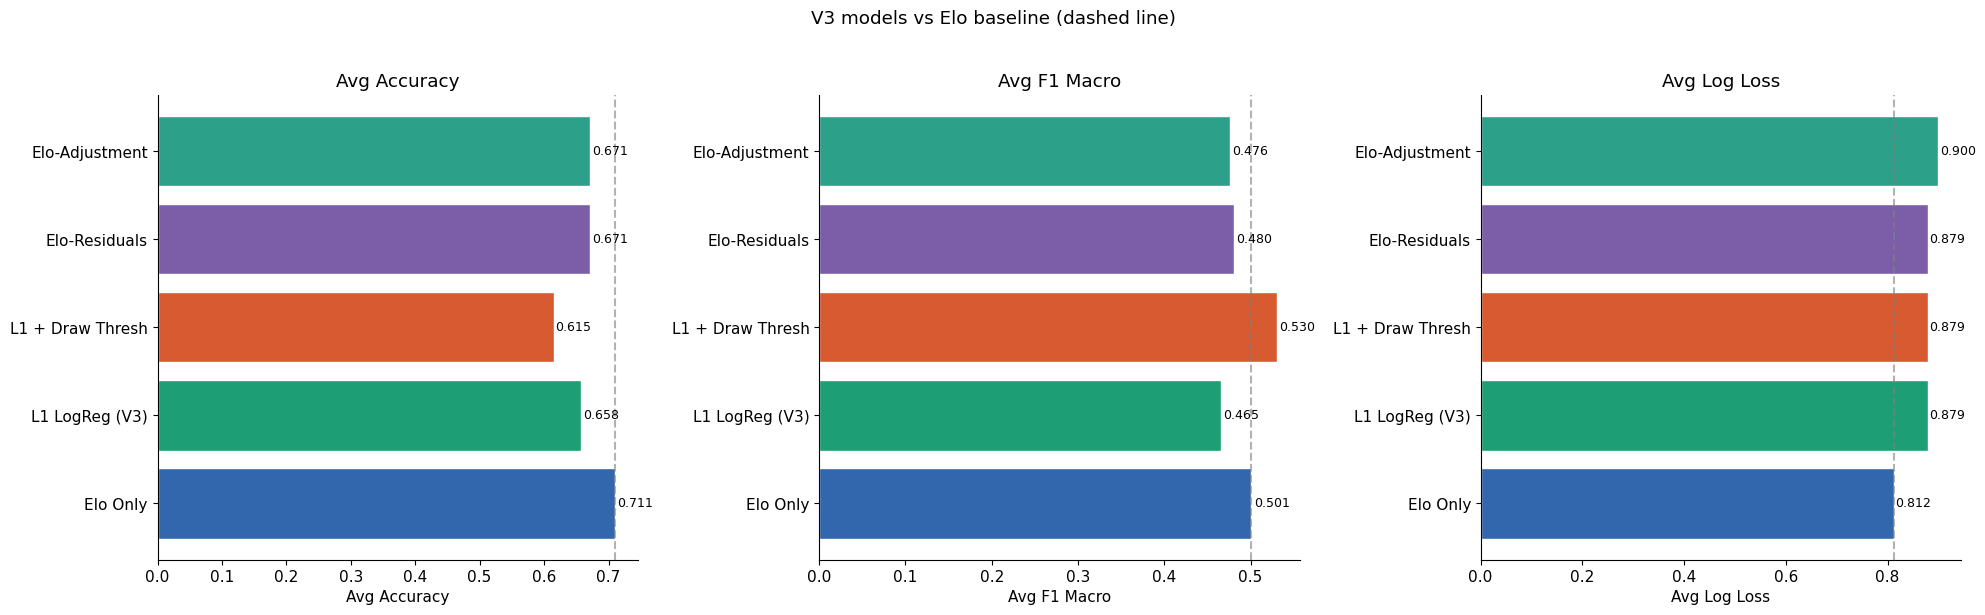

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics = ["Avg Accuracy", "Avg F1 Macro", "Avg Log Loss"]
colors = ["#3266ad", "#1D9E75", "#D85A30", "#7B5EA7", "#2CA089"]

for ax, metric in zip(axes, metrics):
    bars = ax.barh(
        comparison["Model"],
        comparison[metric],
        color=colors[: len(comparison)],
        edgecolor="white",
    )
    elo_val = comparison.loc[comparison["Model"] == "Elo Only", metric].values[0]
    ax.axvline(elo_val, color="gray", ls="--", alpha=0.6)
    ax.set_xlabel(metric)
    ax.set_title(metric)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(
            bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            ha="left",
            va="center",
            fontsize=9,
        )

plt.suptitle("V3 models vs Elo baseline (dashed line)", y=1.02)
plt.tight_layout()
plt.show()

## 5.11 Feature Importance

=== Coefficient stability (Win class) ===
                              2014    2018    2022    mean     std
diff_elo_rating             0.9504  1.7381  1.7635  1.4840  0.3775
diff_GK_clean_sheet_rate    0.0000  0.1796  0.1233  0.1010  0.0750
mismatch_away_attack        0.0000  0.0670  0.0990  0.0553  0.0412
diff_MF_assists_per_app     0.0988  0.0000  0.0000  0.0329  0.0466
diff_squad_assists_per_app  0.0096  0.0000  0.0000  0.0032  0.0045
diff_FW_avg_mv              0.0000  0.0000  0.0000  0.0000  0.0000
diff_FW_goals_elo_wt        0.0000  0.0000  0.0000  0.0000  0.0000
diff_MF_assists_elo_wt      0.0000  0.0000  0.0000  0.0000  0.0000
diff_squad_club_pairs       0.0000  0.0000  0.0000  0.0000  0.0000
diff_squad_avg_club_elo     0.0000  0.0000 -0.0648 -0.0216  0.0305
diff_FW_goals_per_app       0.0000 -0.0711  0.0000 -0.0237  0.0335
diff_wc_pedigree_wins       0.0000  0.0000 -0.1447 -0.0482  0.0682
diff_squad_goals_per_app    0.0000 -0.0075 -0.1829 -0.0635  0.0845
diff_squad_avg_club_

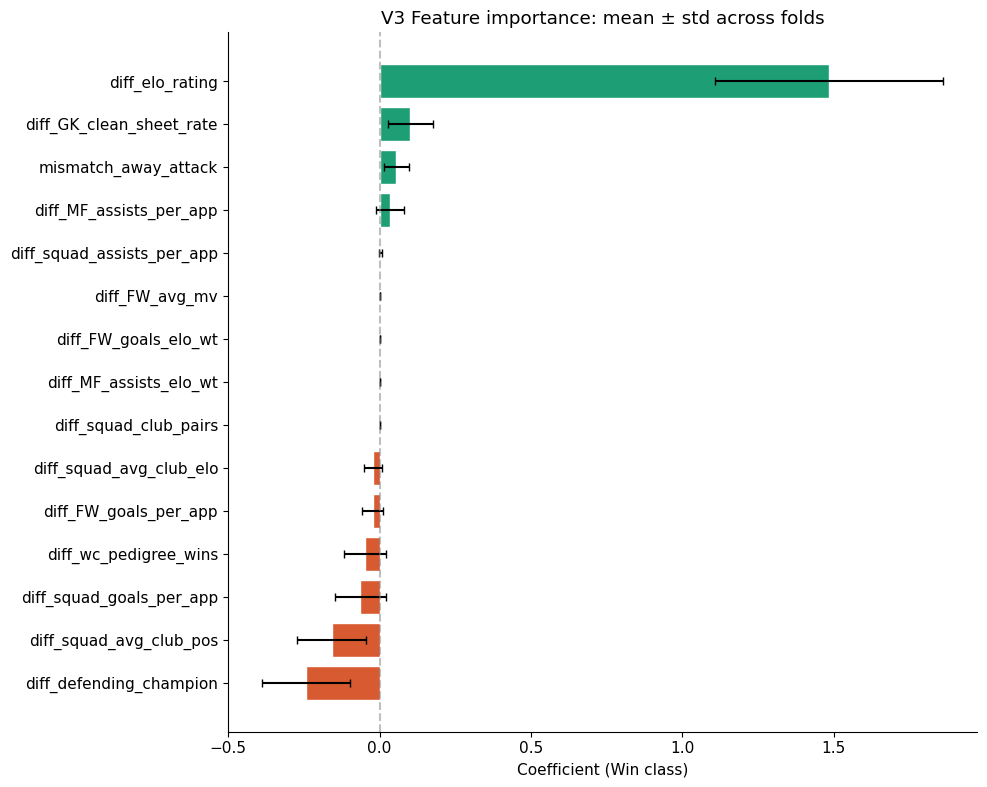

In [ ]:
all_coefs = []
for fold_name, model in l1_models.items():
    clf = model.named_steps["clf"]
    win_idx = list(clf.classes_).index(2)
    coefs = clf.coef_[win_idx]
    all_coefs.append(pd.Series(coefs, index=feat_cols_final, name=fold_name))

coef_stability = pd.DataFrame(all_coefs).T
coef_stability["mean"] = coef_stability.mean(axis=1)
coef_stability["std"] = coef_stability.std(axis=1)
coef_stability = coef_stability.sort_values("mean", ascending=False)

print("=== Coefficient stability (Win class) ===")
print(coef_stability.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(coef_stability))
ax.barh(
    y_pos,
    coef_stability["mean"],
    xerr=coef_stability["std"],
    color=["#1D9E75" if v > 0 else "#D85A30" for v in coef_stability["mean"]],
    edgecolor="white",
    capsize=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_stability.index)
ax.axvline(0, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("Coefficient (Win class)")
ax.set_title("V3 Feature importance: mean \u00b1 std across folds")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5.12 Confusion Matrices (Best Model)

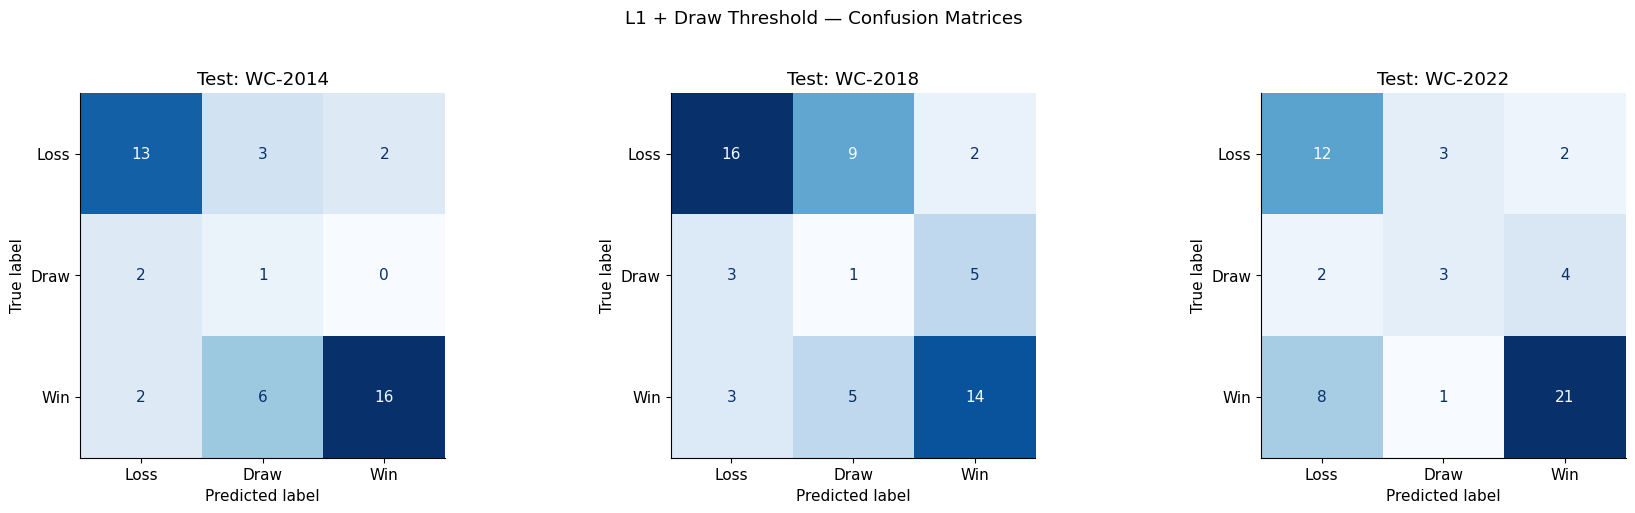

In [21]:
# Pick the best-performing approach for confusion matrices
fig, axes = plt.subplots(1, len(FOLDS), figsize=(6 * len(FOLDS), 5))
for ax, (fold_name, train_years, test_year) in zip(axes, FOLDS):
    test = clean[clean["wc_year"] == test_year]
    if fold_name not in l1_models or len(test) == 0:
        continue
    model = l1_models[fold_name]
    classes = model.named_steps["clf"].classes_
    eps = best_eps.get(fold_name, 0.1)

    probas = model.predict_proba(test[feat_cols_final])
    preds = predict_with_draw_threshold(probas, classes, eps)

    cm = confusion_matrix(test["result_enc"], preds, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Loss", "Draw", "Win"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Test: WC-{test_year}")

plt.suptitle("L1 + Draw Threshold — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

## 5.13 Summary

*To be filled after running.*

1. Did the enriched feature set (club Elo weighting, mismatch, pedigree, cohesion) beat Elo?
2. Which new features survived L1?
3. Did the Elo-residual or Elo-adjustment approach unlock complementary signal?
4. What is the honest conclusion about player-level club stats vs institutional rankings?